# Historic trends — HF datasets

Port of the main visualisations from the capstone's `hf_main_historic_trends.ipynb`
(models), transferred to the weekly *datasets* min files. `# %%` cell markers let
VS Code run this file cell-by-cell in the interactive window, or run it top-to-
bottom as a plain script.

Differences vs the models original:
  - License is NOT a separate column here — it is derived from `license:*`
    entries in `tags`. Tags exist since the first snapshot (2024-07-24, ~27%
    license coverage), so license trends cover the FULL range, not just from
    2025-02-26 like for models.
  - The min files are UNFILTERED (no activity threshold), so counts describe the
    whole hub population and "newly added" reflects actual first appearances,
    with no threshold-change artifact at 2025-02-26.
  - Like the models data, the datasets snapshots have FROZEN upstream weeks
    (identical to the previous week; verified via identical row-count + likes-sum
    signatures): 2024-08-07, 2025-07-02, 2025-11-12, 2025-11-19, 2026-04-08,
    2026-05-27, 2026-06-03. Weekly-delta views (newly added, spike scan) show ~0
    at those weeks and a doubled value the week after.
  - `downloadsAllTime` is still NULL before 2025-02-26 (same era boundary).

In [2]:
# Setup
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter, PercentFormatter

# Match the typography / theme used across the thesis figures.
sns.set_theme(style="whitegrid", context="paper", font="serif")
plt.rcParams.update({
    "figure.dpi": 150,
    "axes.titleweight": "bold",
    "legend.frameon": False,
})
ORG_TYPE_COLORS = {'individual': (0.7, 0.7, 0.7),
 'company': (0.8705882352941177, 0.5607843137254902, 0.0196078431372549),
 'community': (0.00784313725490196, 0.6196078431372549, 0.45098039215686275),
 'non-profit': (0.8352941176470589, 0.3686274509803922, 0.0),
 'university': (0.8, 0.47058823529411764, 0.7372549019607844),
 'classroom': (0.792156862745098, 0.5686274509803921, 0.3803921568627451),
 'government': (0.00392156862745098, 0.45098039215686275, 0.6980392156862745)}

HIST_DATA_DIR = "data/hf_datasets_historic"

first_date = "2024-07-24"

# Snapshot date from which on downloadsAllTime becomes available.
more_extensive_data_date = "2025-02-26"

SNAPSHOT_RE = re.compile(r"hf_datasets_min_(\d{4}-\d{2}-\d{2})\.parquet$")


def _snapshot_files(hist_dir: str, start_date: str) -> list[tuple[pd.Timestamp, Path]]:
    start = pd.Timestamp(start_date)
    out = []
    for p in Path(hist_dir).glob("hf_datasets_min_*.parquet"):
        m = SNAPSHOT_RE.search(p.name)
        if not m:
            continue
        d = pd.Timestamp(m.group(1))
        if d >= start:
            out.append((d, p))
    return sorted(out)


def _fmt_big(v, _pos=None):
    if v >= 1e9:
        return f"{v/1e9:.1f}B"
    if v >= 1e6:
        return f"{v/1e6:.0f}M"
    if v >= 1e3:
        return f"{v/1e3:.0f}K"
    return f"{v:.0f}"


def metric_by_org_type_over_time(
    metric: str,
    start_date: str,
    hist_dir: str = HIST_DATA_DIR,
) -> pd.DataFrame:
    """Sum `metric` per org_type for each weekly snapshot >= start_date.

    Reads only the two needed columns per parquet so memory stays flat across
    the walk. Rows with a missing org_type are treated as 'individual'.
    Returns a wide DataFrame indexed by snapshot date, one column per org_type.
    """
    rows = []
    for d, p in _snapshot_files(hist_dir, start_date):
        df = pd.read_parquet(p, columns=["org_type", metric])
        df["org_type"] = df["org_type"].fillna("individual")
        s = df.groupby("org_type")[metric].sum()
        s.name = d
        rows.append(s)
    wide = pd.concat(rows, axis=1).T.fillna(0).sort_index()
    wide.index.name = "snapshot"
    return wide

# Downloads (all-time) over time

In [3]:
dl_by_org = metric_by_org_type_over_time("downloadsAllTime", more_extensive_data_date)
dl_by_org.tail()

org_type,classroom,community,company,government,individual,non-profit,university
snapshot,,,,,,,
2026-06-17,4131204,474351185,484181409,914033,1448055070,369605747,248644433
2026-06-24,4192094,481357033,489326967,925049,1473914667,373677798,250724959
2026-07-01,4309564,489614605,494765690,673232,1505802113,380608188,253266816
2026-07-08,4421563,496553904,500165713,691079,1536058933,388923863,256126338
2026-07-15,4511392,501453930,504554625,700909,1560499658,393574618,258218808


Total all-time downloads of datasets per org type (individuals excluded)


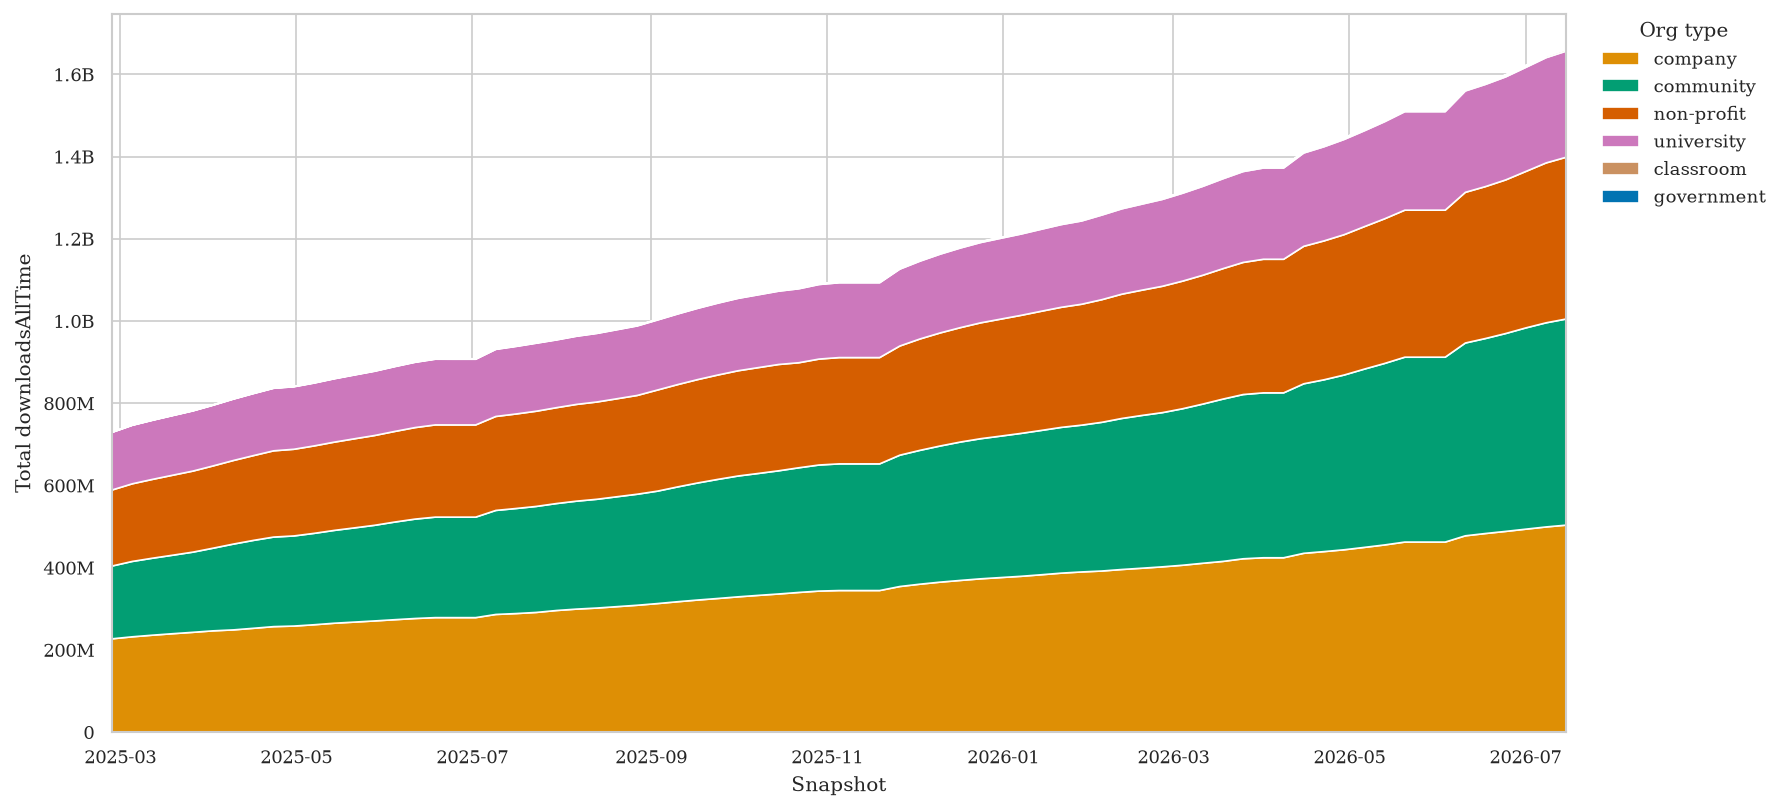

In [4]:
include_individuals = False  # toggle to True to add the 'individual' band

# Keep only org_types we have a colour for; optionally drop 'individual'.
cols = [
    c for c in dl_by_org.columns
    if c in ORG_TYPE_COLORS and (include_individuals or c != "individual")
]
# Largest-on-bottom ordering, ranked by the most recent snapshot's totals
cols = list(dl_by_org[cols].iloc[-1].sort_values(ascending=False).index)
plot_df = dl_by_org[cols]

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.stackplot(
    plot_df.index,
    plot_df.T.values,
    labels=plot_df.columns,
    colors=[ORG_TYPE_COLORS[c] for c in plot_df.columns],
)
ax.set_xlabel("Snapshot")
ax.set_ylabel("Total downloadsAllTime")
ax.legend(title="Org type", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
ax.margins(x=0)
ax.yaxis.set_major_formatter(FuncFormatter(_fmt_big))
print("Total all-time downloads of datasets per org type (individuals excluded)")
fig.tight_layout()
plt.show()

# Downloads (30-day) over time

In [5]:
dn_by_org = metric_by_org_type_over_time("downloads", first_date)
dn_by_org.tail()

org_type,classroom,community,company,government,individual,non-profit,university
snapshot,,,,,,,
2026-06-17,303532,26021480,22363985,57557,115634518,15351366,9920854
2026-06-24,215178,26345962,22592079,46060,109759028,15126716,9024308
2026-07-01,303238,28047580,23468630,40689,115771457,18311190,9330961
2026-07-08,362561,28765793,23584521,50537,119765081,22982728,9850990
2026-07-15,420387,28391599,21953016,54174,122619552,24436844,9974280


Share of 30-day dataset downloads per org type (individuals excluded); black line = absolute total


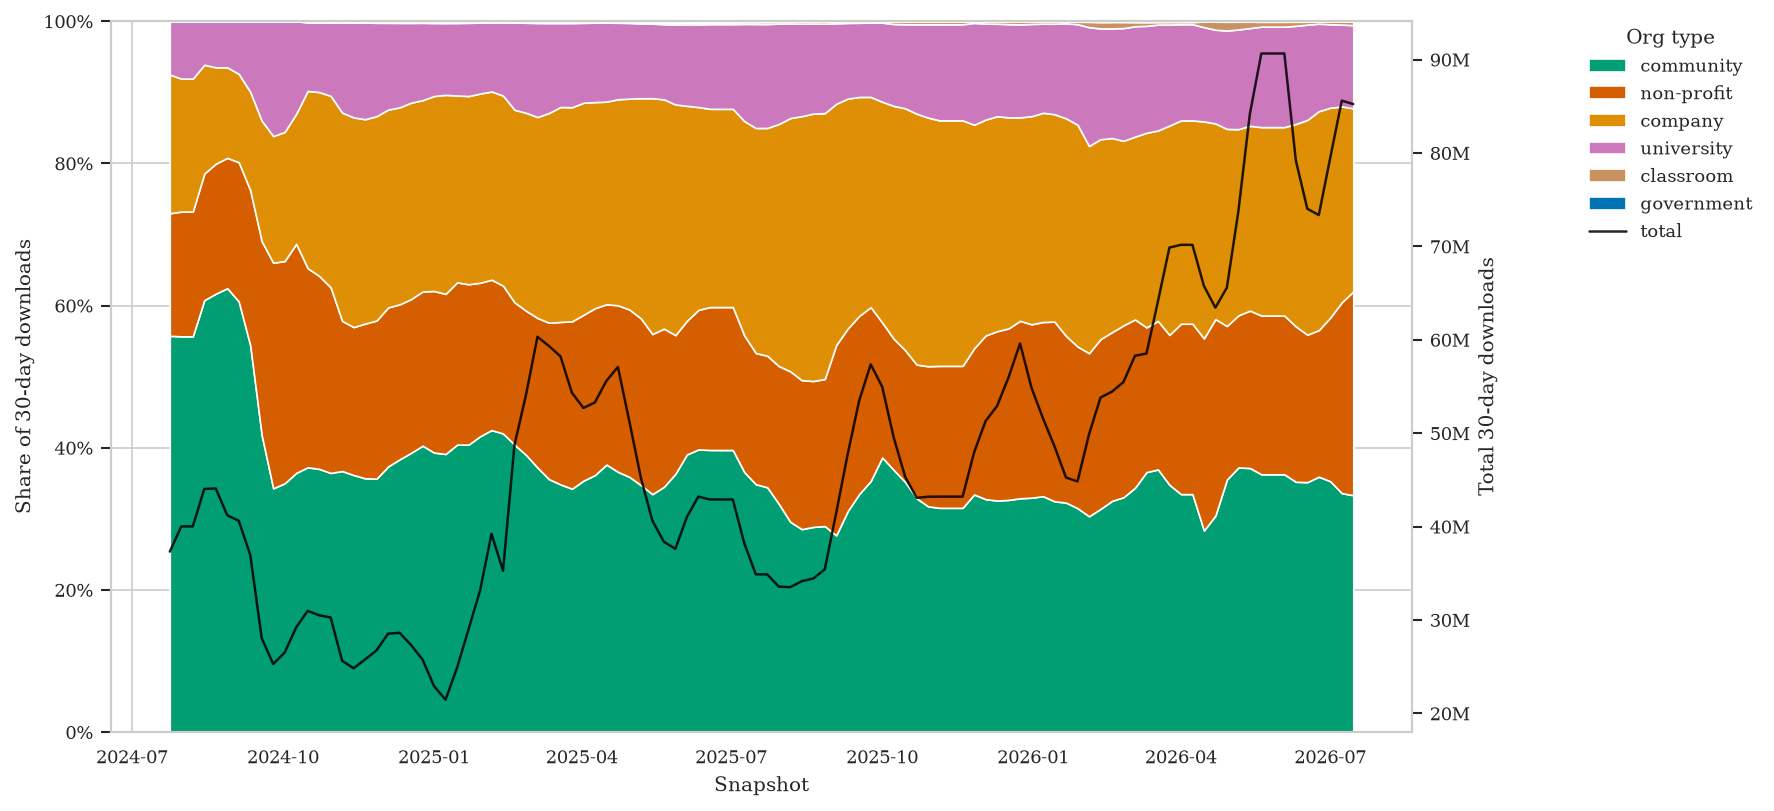

In [6]:
include_individuals = False  # toggle to True to add the 'individual' band

cols = [
    c for c in dn_by_org.columns
    if c in ORG_TYPE_COLORS and (include_individuals or c != "individual")
]
cols = list(dn_by_org[cols].iloc[-1].sort_values(ascending=False).index)
plot_df = dn_by_org[cols]

# Shares are computed AFTER excluding individuals, so percentages sum to 100%
# across the kept org types.
shares = plot_df.div(plot_df.sum(axis=1), axis=0)
totals = plot_df.sum(axis=1)

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.stackplot(
    shares.index,
    shares.T.values,
    labels=shares.columns,
    colors=[ORG_TYPE_COLORS[c] for c in shares.columns],
)
ax.set_xlabel("Snapshot")
ax.set_ylabel("Share of 30-day downloads")
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
ax.set_ylim(0, 1)
ax.margins(x=0)

# Secondary axis: absolute total per snapshot.
ax2 = ax.twinx()
(total_line,) = ax2.plot(
    totals.index, totals.values,
    color="black", linewidth=1.2, alpha=0.85,
)
ax2.set_ylabel("Total 30-day downloads")
ax2.yaxis.set_major_formatter(FuncFormatter(_fmt_big))
ax2.grid(False)

# Single legend that includes the total line as an extra entry.
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles + [total_line],
    labels + ["total"],
    title="Org type",
    bbox_to_anchor=(1.13, 1),
    loc="upper left",
    borderaxespad=0,
)
print("Share of 30-day dataset downloads per org type (individuals excluded); black line = absolute total")
fig.tight_layout()
plt.show()

In [7]:
# Top-N overlay: how much of each org type's downloads come from its top N datasets
TOP_N = 10
include_individuals = True  # toggle to True to add the 'individual' band


def topn_downloads_by_org_over_time(
    start_date: str,
    n: int,
    hist_dir: str = HIST_DATA_DIR,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """For each snapshot, return per-org-type total and top-N-dataset sum of `downloads`.

    Top-N is taken per snapshot per org_type (the N datasets with the largest
    `downloads` in that snapshot), so the darker band can drift as different
    datasets dominate week to week.
    """
    totals_rows, topn_rows = [], []
    for d, p in _snapshot_files(hist_dir, start_date):
        df = pd.read_parquet(p, columns=["org_type", "downloads"])
        df["org_type"] = df["org_type"].fillna("individual")
        total = df.groupby("org_type")["downloads"].sum()
        topn = (
            df.sort_values("downloads", ascending=False)
              .groupby("org_type", sort=False)["downloads"]
              .apply(lambda s: s.head(n).sum())
        )
        total.name = topn.name = d
        totals_rows.append(total)
        topn_rows.append(topn)
    totals = pd.concat(totals_rows, axis=1).T.fillna(0).sort_index()
    topn = pd.concat(topn_rows, axis=1).T.fillna(0).sort_index()
    totals.index.name = topn.index.name = "snapshot"
    return totals, topn


dn_total, dn_topn = topn_downloads_by_org_over_time(first_date, TOP_N)

30-day dataset downloads per org type; darker band = that org type's top 10 datasets


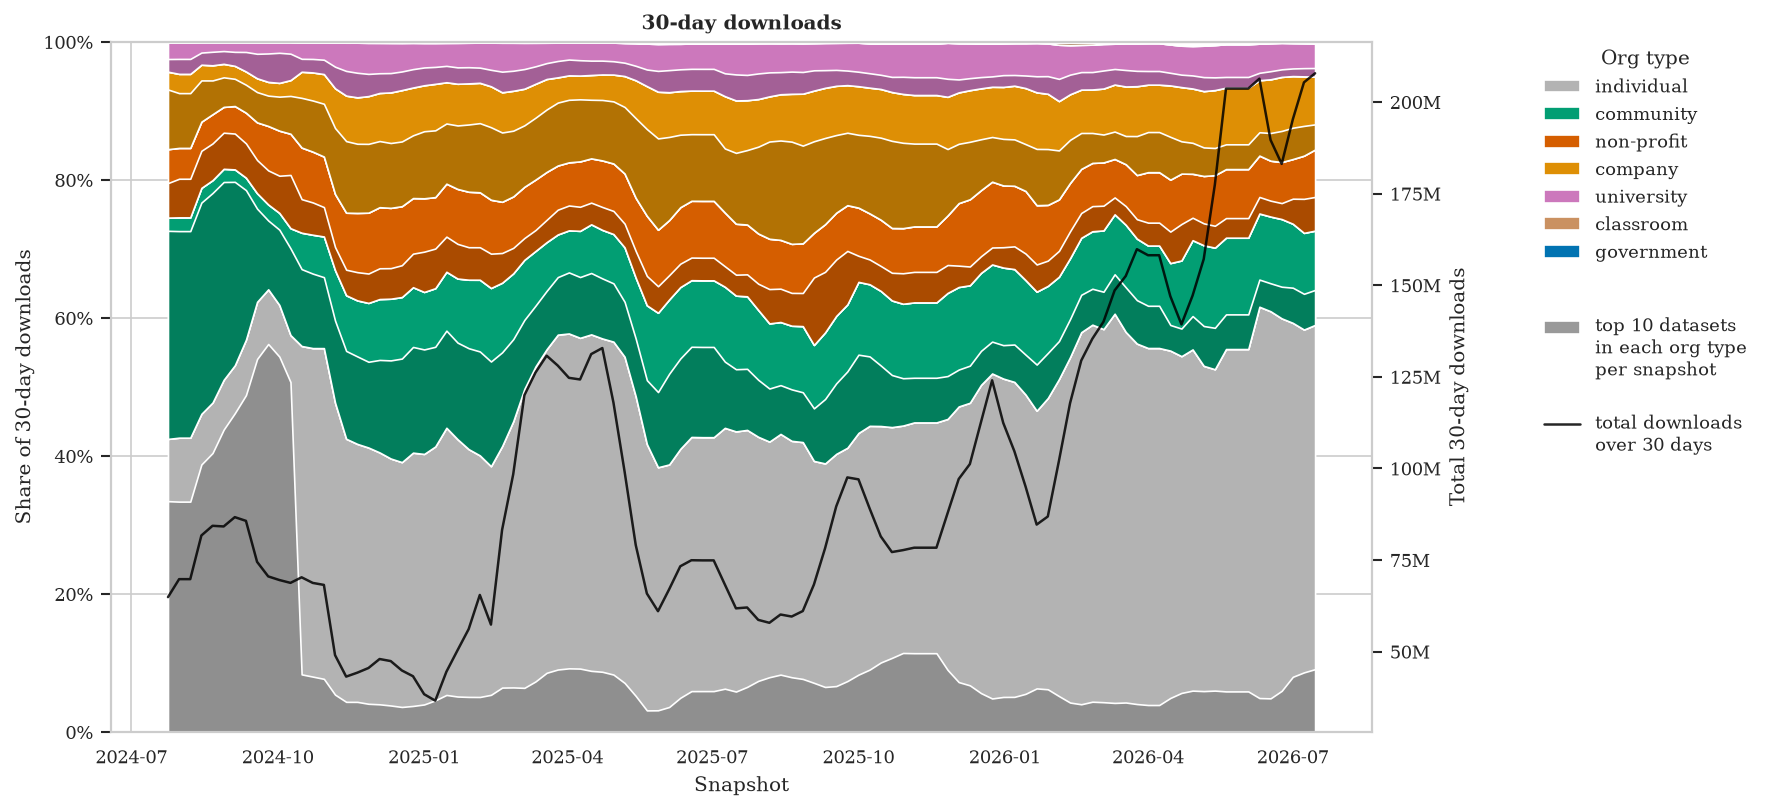

In [8]:
cols = [
    c for c in dn_total.columns
    if c in ORG_TYPE_COLORS and (include_individuals or c != "individual")
]
cols = list(dn_total[cols].iloc[-1].sort_values(ascending=False).index)
total_kept = dn_total[cols]
topn_kept = dn_topn[cols]

# Same denominator for both shares -> the darker slice is literally the share
# of total downloads that comes from the top-N datasets of that org type.
denom = total_kept.sum(axis=1)
shares = total_kept.div(denom, axis=0)
topn_shares = topn_kept.div(denom, axis=0)
totals = denom


def _darker(rgb, factor=0.8):
    """Multiply RGB by `factor` (clamped) to get a darker shade of the same hue."""
    return tuple(max(0.0, min(1.0, c * factor)) for c in rgb)


fig, ax = plt.subplots(figsize=(12, 5.5))

# Manual stacking so we can paint two layers per band: the full org-type slice,
# then a darker overlay at the bottom for the top-N contribution.
lo = pd.Series(0.0, index=shares.index)
for c in cols:
    band = shares[c]
    top = topn_shares[c].clip(upper=band)  # safety: top-N can't exceed the band
    hi = lo + band
    ax.fill_between(shares.index, lo, hi, facecolor=ORG_TYPE_COLORS[c], label=c)
    ax.fill_between(shares.index, lo, lo + top, facecolor=_darker(ORG_TYPE_COLORS[c]))
    lo = hi

ax.set_xlabel("Snapshot")
ax.set_ylabel("Share of 30-day downloads")
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
ax.set_ylim(0, 1)
ax.margins(x=0)

ax2 = ax.twinx()
(total_line,) = ax2.plot(
    totals.index, totals.values,
    color="black", linewidth=1.2, alpha=0.85,
)
ax2.set_ylabel("Total 30-day downloads")
ax2.yaxis.set_major_formatter(FuncFormatter(_fmt_big))
ax2.grid(False)

handles, labels = ax.get_legend_handles_labels()
topn_handle = Patch(facecolor=_darker((0.75, 0.75, 0.75)))
ax.legend(
    handles + [topn_handle, total_line],
    labels + [f"\n\ntop {TOP_N} datasets\nin each org type\nper snapshot", "\ntotal downloads\nover 30 days"],
    title="Org type",
    bbox_to_anchor=(1.13, 1),
    loc="upper left",
    borderaxespad=0,
)
ax.set_title("30-day downloads")
print(f"30-day dataset downloads per org type; darker band = that org type's top {TOP_N} datasets")
fig.tight_layout()
plt.show()

In [9]:
# Top-N ORG overlay: how much of each org type's downloads come from its top N
# organisations (accounts). Unlike the dataset view above, downloads are pooled
# per author first, so an org with several popular datasets counts once.
TOP_N_ORGS = 10
include_individuals = True  # toggle to True to add the 'individual' band


def topn_org_downloads_by_org_type_over_time(
    start_date: str,
    n: int,
    hist_dir: str = HIST_DATA_DIR,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Per snapshot, per-org-type total and top-N-organisation sum of `downloads`.

    Downloads are summed per author (organisation/account) within each org_type
    before ranking, so the darker band measures account-level concentration
    rather than single-dataset hits.
    """
    totals_rows, topn_rows = [], []
    for d, p in _snapshot_files(hist_dir, start_date):
        df = pd.read_parquet(p, columns=["author", "org_type", "downloads"])
        df["org_type"] = df["org_type"].fillna("individual")
        by_author = df.groupby(["org_type", "author"])["downloads"].sum()
        total = by_author.groupby(level="org_type").sum()
        topn = by_author.groupby(level="org_type").apply(lambda s: s.nlargest(n).sum())
        total.name = topn.name = d
        totals_rows.append(total)
        topn_rows.append(topn)
    totals = pd.concat(totals_rows, axis=1).T.fillna(0).sort_index()
    topn = pd.concat(topn_rows, axis=1).T.fillna(0).sort_index()
    totals.index.name = topn.index.name = "snapshot"
    return totals, topn


dn_total_orgs, dn_topn_orgs = topn_org_downloads_by_org_type_over_time(first_date, TOP_N_ORGS)

30-day dataset downloads per org type; darker band = that org type's top 10 organisations


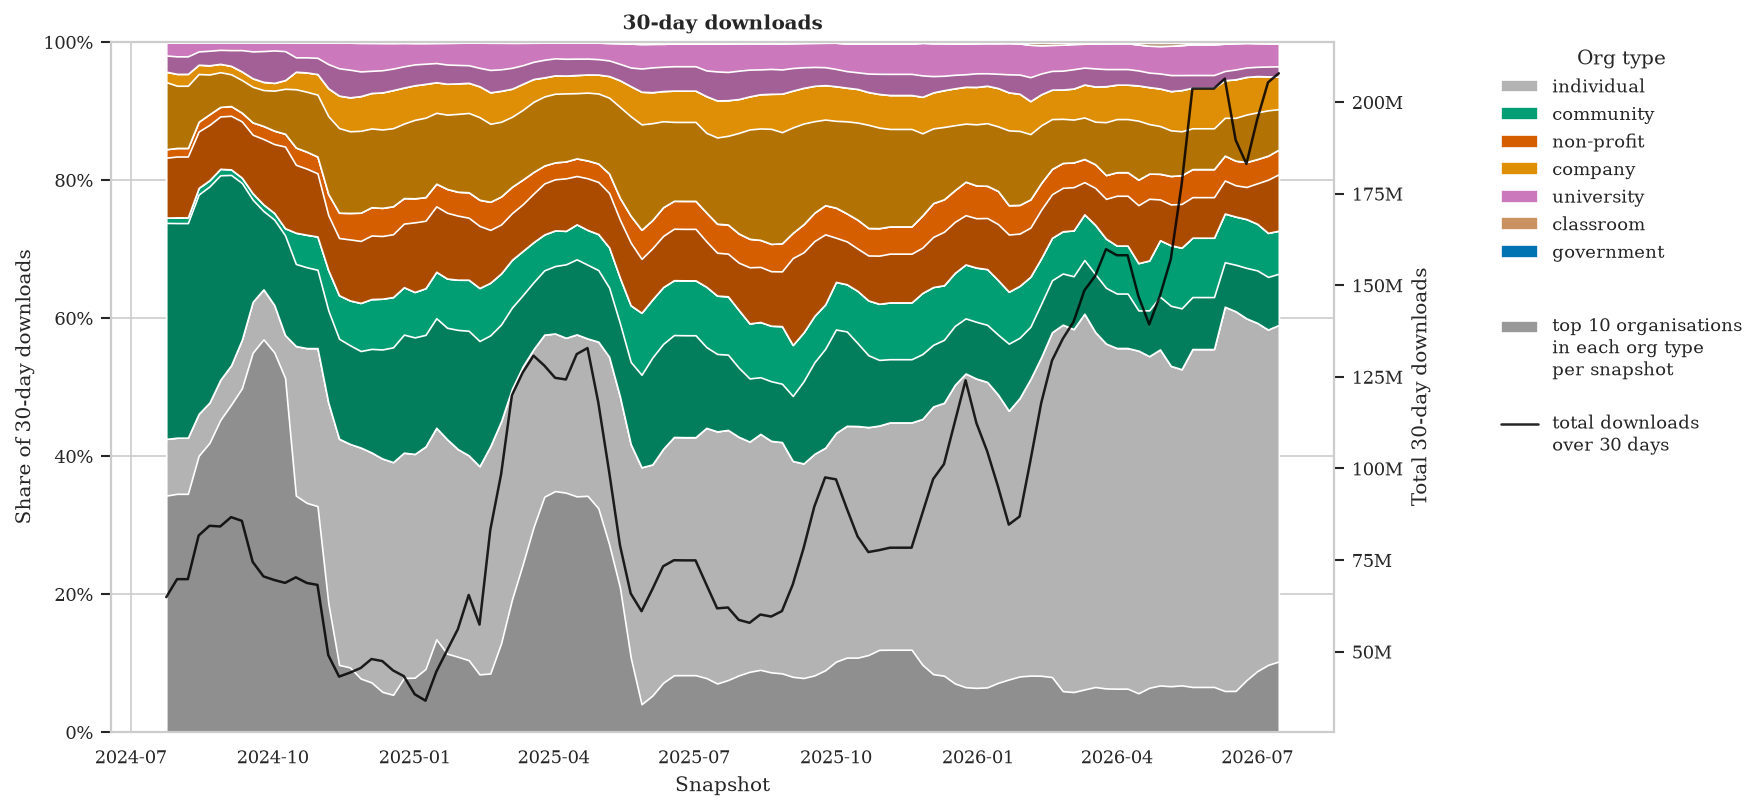

In [10]:
cols = [
    c for c in dn_total_orgs.columns
    if c in ORG_TYPE_COLORS and (include_individuals or c != "individual")
]
cols = list(dn_total_orgs[cols].iloc[-1].sort_values(ascending=False).index)
total_kept = dn_total_orgs[cols]
topn_kept = dn_topn_orgs[cols]

# Same denominator for both shares -> the darker slice is literally the share
# of total downloads that comes from the top-N organisations of that org type.
denom = total_kept.sum(axis=1)
shares = total_kept.div(denom, axis=0)
topn_shares = topn_kept.div(denom, axis=0)
totals = denom

fig, ax = plt.subplots(figsize=(12, 5.5))

# Manual stacking: full org-type slice, then a darker overlay at the bottom for
# the contribution of that org type's top-N organisations.
lo = pd.Series(0.0, index=shares.index)
for c in cols:
    band = shares[c]
    top = topn_shares[c].clip(upper=band)  # safety: top-N can't exceed the band
    hi = lo + band
    ax.fill_between(shares.index, lo, hi, facecolor=ORG_TYPE_COLORS[c], label=c)
    ax.fill_between(shares.index, lo, lo + top, facecolor=_darker(ORG_TYPE_COLORS[c]))
    lo = hi

ax.set_xlabel("Snapshot")
ax.set_ylabel("Share of 30-day downloads")
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
ax.set_ylim(0, 1)
ax.margins(x=0)

ax2 = ax.twinx()
(total_line,) = ax2.plot(
    totals.index, totals.values,
    color="black", linewidth=1.2, alpha=0.85,
)
ax2.set_ylabel("Total 30-day downloads")
ax2.yaxis.set_major_formatter(FuncFormatter(_fmt_big))
ax2.grid(False)

handles, labels = ax.get_legend_handles_labels()
topn_handle = Patch(facecolor=_darker((0.75, 0.75, 0.75)))
ax.legend(
    handles + [topn_handle, total_line],
    labels + [f"\n\ntop {TOP_N_ORGS} organisations\nin each org type\nper snapshot", "\ntotal downloads\nover 30 days"],
    title="Org type",
    bbox_to_anchor=(1.13, 1),
    loc="upper left",
    borderaxespad=0,
)
ax.set_title("30-day downloads")
print(f"30-day dataset downloads per org type; darker band = that org type's top {TOP_N_ORGS} organisations")
fig.tight_layout()
plt.show()

In [11]:
# Top-N membership: which datasets sit in the weekly top-N, and how persistently


def topn_membership_over_time(
    start_date: str,
    n: int,
    hist_dir: str = HIST_DATA_DIR,
) -> pd.DataFrame:
    """Per-snapshot per-org-type top-N membership, with average within-org share.

    For each weekly snapshot, take the N datasets with the largest `downloads`
    within each org_type. Returns one row per (dataset, org_type) ever seen in
    top-N, with the count of snapshots and the mean share of org_type downloads
    the dataset held *during those top-N snapshots*.
    """
    rows = []
    snapshots = _snapshot_files(hist_dir, start_date)
    for _, p in snapshots:
        df = pd.read_parquet(p, columns=["_id", "id", "org_type", "downloads"])
        df["org_type"] = df["org_type"].fillna("individual")
        org_total = df.groupby("org_type")["downloads"].transform("sum")
        df["share"] = df["downloads"] / org_total
        top = (
            df.sort_values("downloads", ascending=False)
              .groupby("org_type", sort=False)
              .head(n)
        )
        rows.append(top[["_id", "id", "org_type", "share"]])

    long = pd.concat(rows, ignore_index=True)
    out = (
        long.groupby(["_id", "org_type"], sort=False)
            .agg(
                id=("id", "last"),  # last-seen human-readable id (in case of rename)
                snapshots_in_topN=("share", "size"),
                avg_share_in_org=("share", "mean"),
            )
            .reset_index()
    )
    out = out[["_id", "id", "org_type", "snapshots_in_topN", "avg_share_in_org"]]
    out = out.sort_values(
        ["snapshots_in_topN", "avg_share_in_org"], ascending=[False, False]
    ).reset_index(drop=True)
    out.attrs["n"] = n
    out.attrs["total_snapshots"] = len(snapshots)
    return out


topn_datasets = topn_membership_over_time(first_date, TOP_N)
print(f"N={topn_datasets.attrs['n']},  snapshots walked = {topn_datasets.attrs['total_snapshots']}")
topn_datasets.head(20)

N=10,  snapshots walked = 104


,_id,id,org_type,snapshots_in_topN,avg_share_in_org
0,621ffdd236468d709f181e3f,nyu-mll/glue,university,104,0.058741
1,621ffdd236468d709f182a80,allenai/c4,non-profit,102,0.048030
2,621ffdd236468d709f181d5e,allenai/ai2_arc,non-profit,100,0.032134
3,621ffdd236468d709f18200d,Salesforce/wikitext,company,98,0.050403
4,64b87fc32f796fffbbf4119b,lavita/medical-qa-shared-task-v1-toy,community,94,0.061282
5,621ffdd236468d709f1835cf,huggingface/documentation-images,company,92,0.200158
6,625552d2b339bb03abe3432d,openai/gsm8k,company,92,0.031245
7,621ffdd236468d709f1835d5,huggingface-course/documentation-images,non-profit,85,0.031951
8,621ffdd236468d709f181e77,stanfordnlp/imdb,university,85,0.023162
9,63977bb96bdef8095268ded0,allenai/objaverse,non-profit,83,0.059192


## Spike attribution (week-over-week delta scan)

Walk every consecutive snapshot pair, join on `_id`, and rank datasets by
`downloads_t − downloads_{t-1}`.

In [12]:
def spike_drivers_full_scan(
    start_date: str = first_date,
    top_per_snapshot: int = 5,
    hist_dir: str = HIST_DATA_DIR,
) -> pd.DataFrame:
    """Top-K week-over-week download spikes per snapshot pair.

    For every consecutive pair (t-1, t), inner-joins on `_id`, computes
    `delta = downloads_t - downloads_{t-1}`, and keeps the top
    `top_per_snapshot` rows by `delta`. Inner join intentionally excludes
    first-appearance cases so the result tracks growth of already-known
    datasets rather than upload spikes.
    """
    snapshots = _snapshot_files(hist_dir, start_date)
    rows = []
    prev = None
    for d, p in snapshots:
        cur = pd.read_parquet(p, columns=["_id", "id", "org_type", "downloads"])
        cur["org_type"] = cur["org_type"].fillna("individual")
        if prev is not None:
            merged = cur.merge(
                prev[["_id", "downloads"]].rename(columns={"downloads": "downloads_prev"}),
                on="_id", how="inner",
            )
            merged["delta"] = merged["downloads"] - merged["downloads_prev"]
            top = merged.nlargest(top_per_snapshot, "delta").copy()
            top["snapshot"] = d
            rows.append(top[["snapshot", "_id", "id", "org_type", "downloads_prev", "downloads", "delta"]])
        prev = cur
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()


spikes = spike_drivers_full_scan(top_per_snapshot=5)
print(f"top 5 spike contributors per snapshot pair — {len(spikes)} rows ({spikes['_id'].nunique()} unique datasets)")
spikes.head(20)

top 5 spike contributors per snapshot pair — 515 rows (207 unique datasets)


,snapshot,_id,id,org_type,downloads_prev,downloads,delta
0,2024-07-31,654138a2a385933e81fdbb4c,hails/mmlu_no_train,individual,17131954,18791156,1659202
1,2024-07-31,64634f50ab15db2fa56693cc,lighteval/mmlu,community,15667283,17075227,1407944
2,2024-07-31,66601bbf8a73e7a3eb8efc68,bigcode/bigcodebench,non-profit,183048,400658,217610
3,2024-07-31,657b4b8f6c149b6a964c4c4b,allenai/reward-bench,non-profit,179503,352959,173456
4,2024-07-31,65645c0a4e74b2075a4f0394,HAERAE-HUB/KMMLU,non-profit,308663,464232,155569
5,2024-08-07,621ffdd236468d709f181d58,amirveyseh/acronym_identification,individual,220,220,0
6,2024-08-07,621ffdd236468d709f181d59,ade-benchmark-corpus/ade_corpus_v2,individual,764,764,0
7,2024-08-07,621ffdd236468d709f181d5a,UCLNLP/adversarial_qa,university,356,356,0
8,2024-08-07,621ffdd236468d709f181d5b,Yale-LILY/aeslc,university,179,179,0
9,2024-08-07,621ffdd236468d709f181d5c,nwu-ctext/afrikaans_ner_corpus,individual,147,147,0


In [13]:
def spike_drivers_summary(spikes: pd.DataFrame, top: int = 25) -> pd.DataFrame:
    """Per-dataset: largest single-week download delta, when, plus top-K appearances."""
    idx = spikes.groupby("_id")["delta"].idxmax()
    out = spikes.loc[idx].copy()
    counts = spikes.groupby("_id").size().rename("topK_appearances")
    out = out.merge(counts, on="_id")
    out = out.sort_values("delta", ascending=False).head(top).reset_index(drop=True)
    return out[["snapshot", "id", "org_type", "downloads_prev", "downloads", "delta", "topK_appearances"]]


spike_drivers_summary(spikes, top=25)

,snapshot,id,org_type,downloads_prev,downloads,delta,topK_appearances
0,2024-08-14,hails/mmlu_no_train,individual,18791156,27998674,9207518,6
1,2024-08-14,lighteval/mmlu,community,17075227,20965458,3890231,5
2,2026-07-01,anisoleai/fineweb-tokenized,individual,152097,3800731,3648634,3
3,2025-09-03,allenai/objaverse,non-profit,745066,4272984,3527918,9
4,2024-10-16,KakologArchives/KakologArchives,community,0,3292623,3292623,19
5,2026-07-01,codeparrot/github-code,non-profit,227629,3017441,2789812,2
6,2024-10-16,huggingface/documentation-images,company,11,2160092,2160081,14
7,2026-03-25,ropedia-ai/xperience-10m,company,4026,2106657,2102631,1
8,2026-05-13,bluuebunny/arxiv_metadata_by_year,individual,16732,1595656,1578924,1
9,2024-10-16,huggingchat/models-logo,community,0,1460702,1460702,2


# Likes over time

In [14]:
lk_by_org = metric_by_org_type_over_time("likes", first_date)
lk_by_org.tail()

org_type,classroom,community,company,government,individual,non-profit,university
snapshot,,,,,,,
2026-06-17,1147,71203,105248,337,256087,57314,42509
2026-06-24,1155,71587,105643,338,258880,57639,42731
2026-07-01,1154,71967,106506,339,261294,57922,42932
2026-07-08,1162,72461,107493,350,264719,58295,43204
2026-07-15,1168,73063,108295,359,268237,58718,43507


Total likes on datasets per org type (individuals excluded)


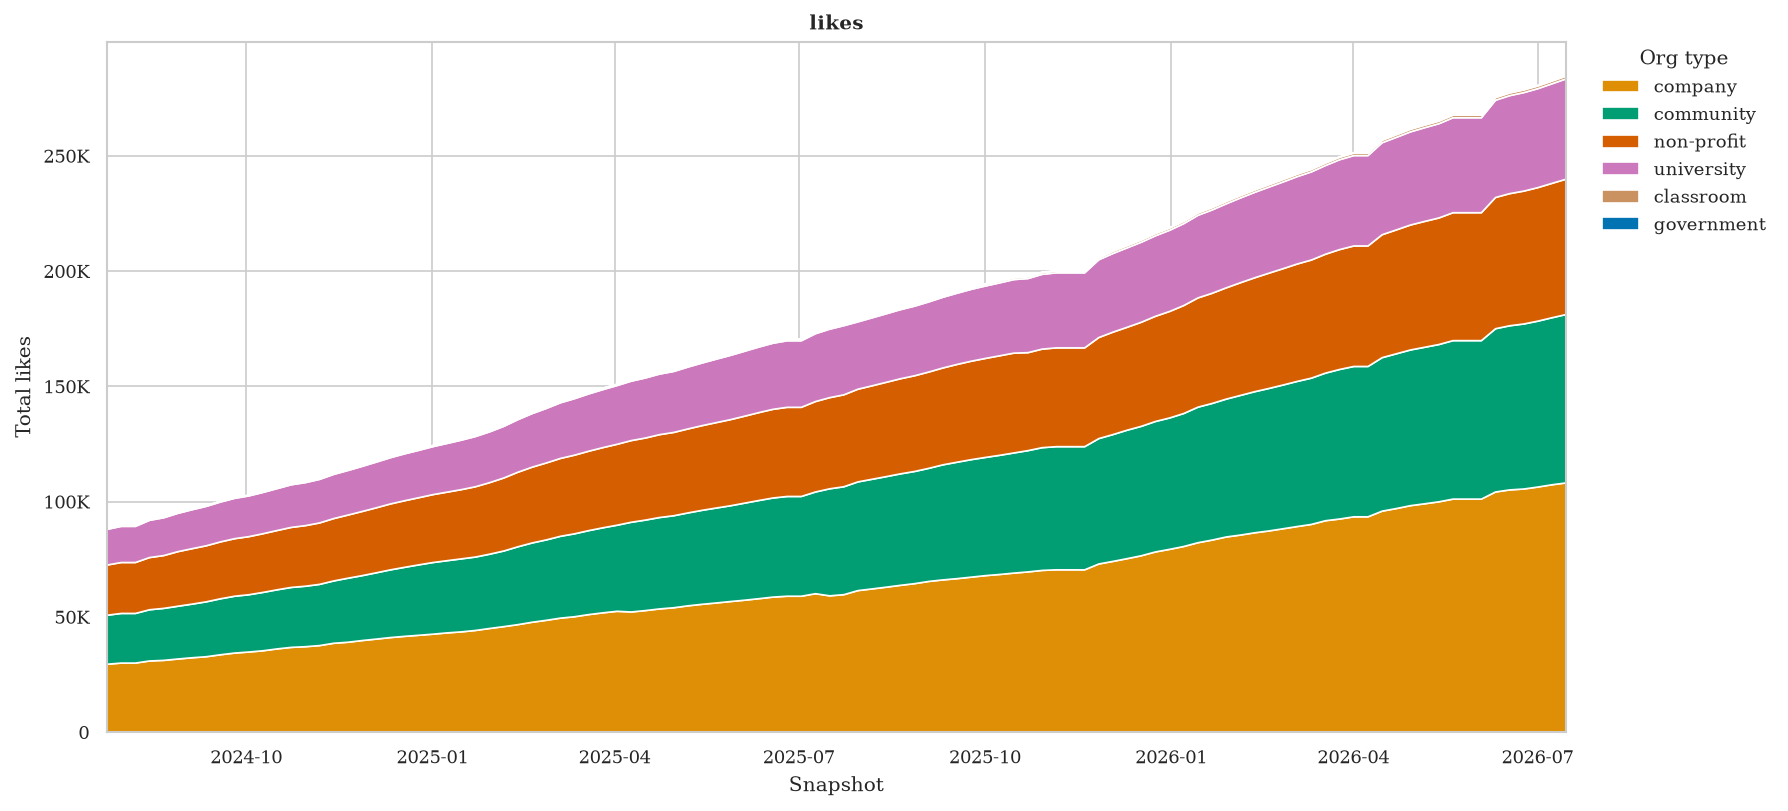

In [15]:
include_individuals = False  # toggle to True to add the 'individual' band

cols = [
    c for c in lk_by_org.columns
    if c in ORG_TYPE_COLORS and (include_individuals or c != "individual")
]
cols = list(lk_by_org[cols].iloc[-1].sort_values(ascending=False).index)
plot_df = lk_by_org[cols]

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.stackplot(
    plot_df.index,
    plot_df.T.values,
    labels=plot_df.columns,
    colors=[ORG_TYPE_COLORS[c] for c in plot_df.columns],
)
ax.set_xlabel("Snapshot")
ax.set_ylabel("Total likes")
ax.legend(title="Org type", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
ax.margins(x=0)
ax.yaxis.set_major_formatter(FuncFormatter(_fmt_big))
ax.set_title("likes")
print("Total likes on datasets per org type (individuals excluded)")
fig.tight_layout()
plt.show()

In [16]:
# Company share of NON-individual likes per snapshot.
# Denominator excludes 'individual' so the metric isolates the split among
# organisational publishers. (The models original computed community/total but
# labelled it company — fixed here to actually use the company column.)
non_ind = lk_by_org.drop(columns=["individual"])
company_share_nonind = non_ind["company"] / non_ind.sum(axis=1)

share_table = pd.DataFrame({
    "company_likes": non_ind["company"],
    "non_individual_likes": non_ind.sum(axis=1),
    "company_share": company_share_nonind,
})
with pd.option_context("display.max_rows", None, "display.float_format", "{:.4f}".format):
    print(share_table)

            company_likes  non_individual_likes  company_share
snapshot                                                      
2024-07-24          29633                 88411         0.3352
2024-07-31          30134                 89711         0.3359
2024-08-07          30134                 89711         0.3359
2024-08-14          31050                 92348         0.3362
2024-08-21          31304                 93450         0.3350
2024-08-28          31898                 95387         0.3344
2024-09-04          32442                 96951         0.3346
2024-09-11          32892                 98417         0.3342
2024-09-18          33739                100293         0.3364
2024-09-25          34478                101902         0.3383
2024-10-02          34920                102945         0.3392
2024-10-09          35468                104462         0.3395
2024-10-16          36277                106135         0.3418
2024-10-23          36947                107804        

# Datasets over time

In [17]:
def dataset_count_by_org_type_over_time(
    start_date: str,
    hist_dir: str = HIST_DATA_DIR,
) -> pd.DataFrame:
    """Count datasets per org_type for each weekly snapshot >= start_date.

    Mirrors metric_by_org_type_over_time but uses row counts instead of a sum.
    Since the min files are unfiltered, this is the full on-Hub population.
    """
    rows = []
    for d, p in _snapshot_files(hist_dir, start_date):
        df = pd.read_parquet(p, columns=["org_type"])
        df["org_type"] = df["org_type"].fillna("individual")
        s = df.groupby("org_type").size()
        s.name = d
        rows.append(s)
    wide = pd.concat(rows, axis=1).T.fillna(0).astype(int).sort_index()
    wide.index.name = "snapshot"
    return wide


dc_by_org = dataset_count_by_org_type_over_time(first_date)
dc_by_org.tail()

org_type,classroom,community,company,government,individual,non-profit,university
snapshot,,,,,,,
2026-06-17,3983,58331,28015,1742,861332,48767,22332
2026-06-24,3996,58489,28181,1745,782190,48917,22458
2026-07-01,3991,58818,28354,682,782128,49036,22426
2026-07-08,4012,59060,28491,685,789207,49095,22610
2026-07-15,4029,59213,28762,691,796017,51632,22847


Number of datasets per org type (individuals excluded; unfiltered population)


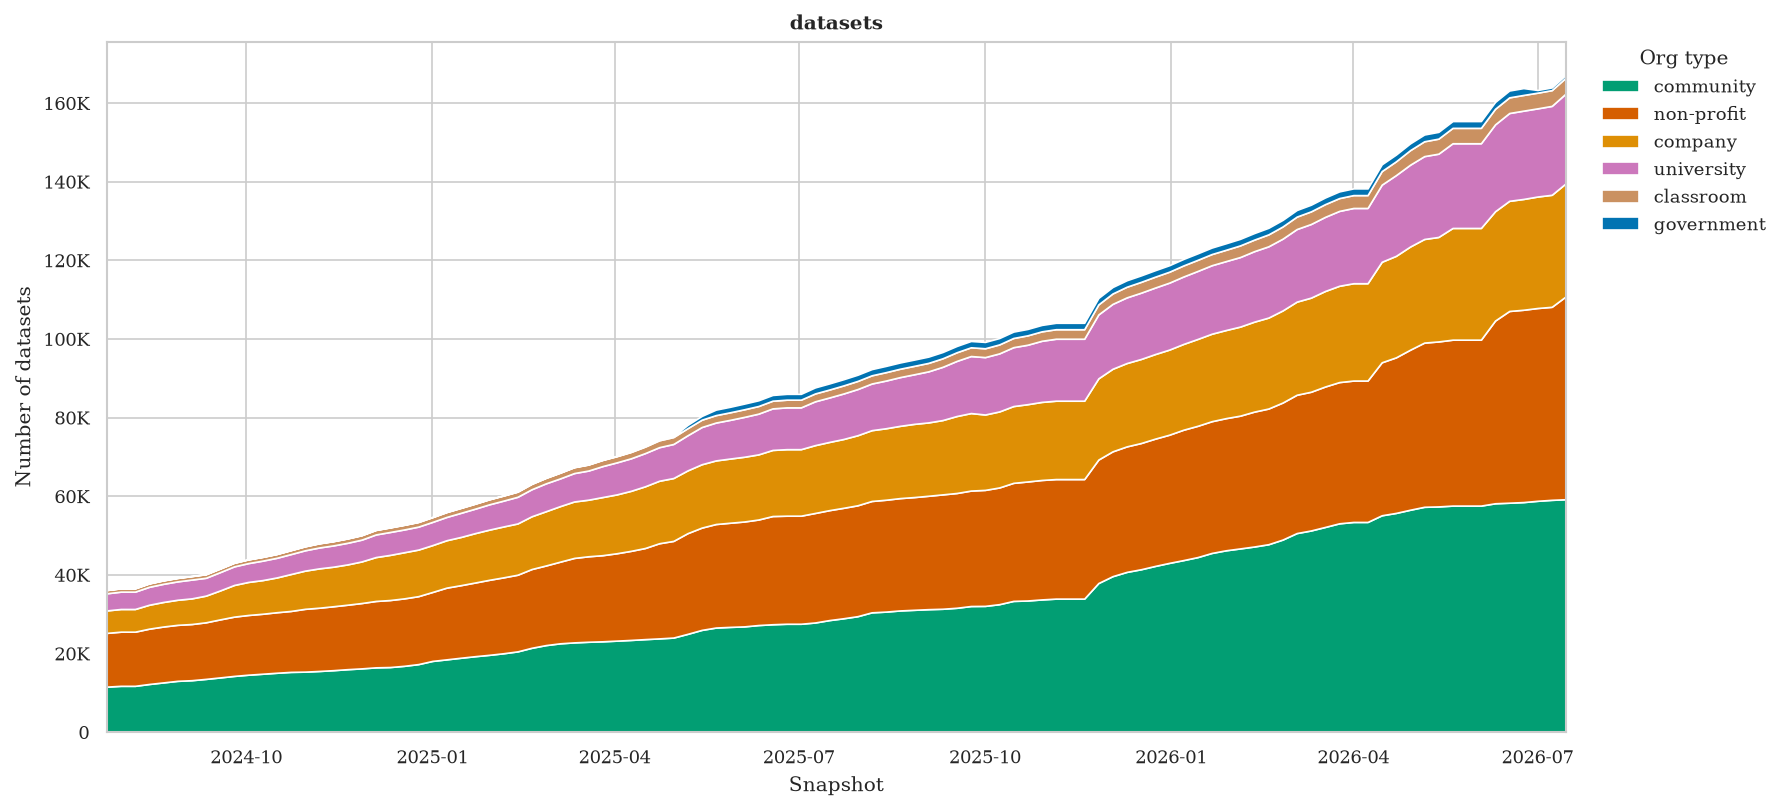

            total_datasets  delta
snapshot                         
2024-07-24          185215      0
2024-07-31          188689   3474
2024-08-07          188689      0
2024-08-14          197535   8846
2024-08-21          201752   4217
2024-08-28          205064   3312
2024-09-04          207859   2795
2024-09-11          211434   3575
2024-09-18          215395   3961
2024-09-25          220104   4709
2024-10-02          223588   3484
2024-10-09          227657   4069
2024-10-16          231321   3664
2024-10-23          235449   4128
2024-10-30          238362   2913
2024-11-06          242609   4247
2024-11-13          246080   3471
2024-11-20          250450   4370
2024-11-27          255172   4722
2024-12-04          258372   3200
2024-12-11          262248   3876
2024-12-18          266246   3998
2024-12-25          270796   4550
2025-01-01          276421   5625
2025-01-08          281918   5497
2025-01-15          287350   5432
2025-01-22          292039   4689
2025-01-29    

In [18]:
include_individuals = False  # toggle to True to add the 'individual' band

cols = [
    c for c in dc_by_org.columns
    if c in ORG_TYPE_COLORS and (include_individuals or c != "individual")
]
cols = list(dc_by_org[cols].iloc[-1].sort_values(ascending=False).index)
plot_df = dc_by_org[cols]

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.stackplot(
    plot_df.index,
    plot_df.T.values,
    labels=plot_df.columns,
    colors=[ORG_TYPE_COLORS[c] for c in plot_df.columns],
)
ax.set_xlabel("Snapshot")
ax.set_ylabel("Number of datasets")
ax.legend(title="Org type", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
ax.margins(x=0)
ax.yaxis.set_major_formatter(FuncFormatter(_fmt_big))
ax.set_title("datasets")
print("Number of datasets per org type (individuals excluded; unfiltered population)")
fig.tight_layout()
plt.show()

# Total dataset count over time (across all org types, including individual,
# so the printed trend reflects the full population — not just the bands shown).
totals = dc_by_org.sum(axis=1).rename("total_datasets").to_frame()
totals["delta"] = totals["total_datasets"].diff().fillna(0).astype(int)
with pd.option_context("display.max_rows", None):
    print(totals)

# Newly added per org type over time

In [19]:
# costly


def newly_added_by_org_type_over_time(
    start_date: str,
    hist_dir: str = HIST_DATA_DIR,
) -> pd.DataFrame:
    """Per-snapshot count of datasets whose `_id` is appearing for the first time.

    Walks snapshots in date order and maintains a cumulative `seen` set of `_id`s.
    Because the min files are unfiltered, first appearance ≈ actual upload week
    (a dataset can only "reappear" if it was deleted/private and came back).
    The first snapshot is all-new by construction (no prior set to diff against)
    and acts as the baseline population.
    """
    rows = []
    seen: set[str] = set()
    for d, p in _snapshot_files(hist_dir, start_date):
        df = pd.read_parquet(p, columns=["_id", "org_type"])
        df["org_type"] = df["org_type"].fillna("individual")
        new = df.loc[~df["_id"].isin(seen)]
        s = new.groupby("org_type").size()
        s.name = d
        rows.append(s)
        seen.update(df["_id"].to_numpy().tolist())
    wide = pd.concat(rows, axis=1).T.fillna(0).astype(int).sort_index()
    wide.index.name = "snapshot"
    return wide


new_by_org = newly_added_by_org_type_over_time(first_date)
new_by_org.tail()

org_type,classroom,community,company,government,individual,non-profit,university
snapshot,,,,,,,
2026-06-17,13,240,248,8,8662,2313,282
2026-06-24,13,212,275,6,9784,153,190
2026-07-01,8,354,253,12,8118,135,131
2026-07-08,23,266,223,3,8385,81,208
2026-07-15,20,184,321,8,8185,2562,256


newly added datasets per snapshot (first-appearance of _id)


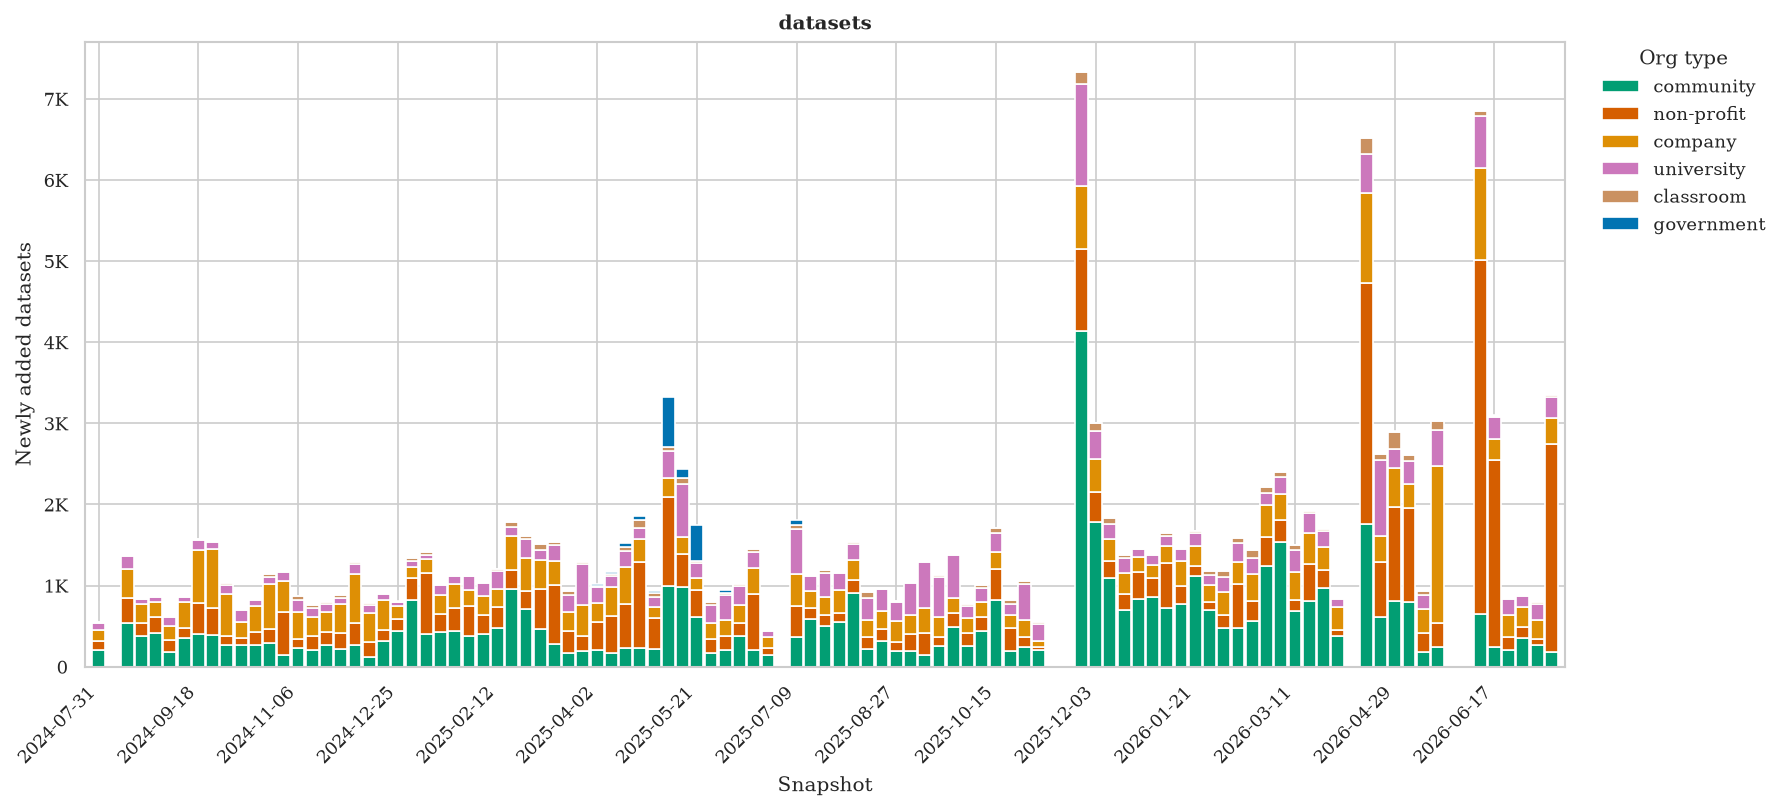

baseline (2024-07-24): 185,215 datasets — first-appearance by construction, omitted from the bar chart
            newly_added  cumulative
snapshot                           
2024-07-24       185215      185215
2024-07-31         4155      189370
2024-08-07            0      189370
2024-08-14         9920      199290
2024-08-21         5015      204305
2024-08-28         4528      208833
2024-09-04         4406      213239
2024-09-11         4751      217990
2024-09-18         5007      222997
2024-09-25         5448      228445
2024-10-02         4787      233232
2024-10-09         4742      237974
2024-10-16         4462      242436
2024-10-23         4992      247428
2024-10-30         4458      251886
2024-11-06         5069      256955
2024-11-13         5297      262252
2024-11-20         5145      267397
2024-11-27         5470      272867
2024-12-04         5895      278762
2024-12-11         4841      283603
2024-12-18         5049      288652
2024-12-25         5105      2937

In [20]:
include_individuals = False  # toggle to True to add the 'individual' band

cols = [
    c for c in new_by_org.columns
    if c in ORG_TYPE_COLORS and (include_individuals or c != "individual")
]
# Rank by total newly-added over the whole window so the largest contributor sits at the bottom.
cols = list(new_by_org[cols].sum().sort_values(ascending=False).index)

# The first snapshot is the baseline population, not a weekly addition — it would
# dwarf every later bar. Drop it from the plot but keep it in the printed table.
plot_df = new_by_org[cols].iloc[1:]

# Categorical x-axis (string labels) avoids pandas' time-series bar pitfall.
x_labels = plot_df.index.strftime("%Y-%m-%d")
xs = range(len(plot_df))

fig, ax = plt.subplots(figsize=(12, 5.5))
bottom = pd.Series(0, index=plot_df.index, dtype=float)
for c in cols:
    ax.bar(
        xs, plot_df[c].values,
        bottom=bottom.values,
        color=ORG_TYPE_COLORS[c], label=c, width=0.9,
    )
    bottom = bottom + plot_df[c]

# NOTE: the models version annotated 2025-02-26 (filter threshold change) —
# not applicable here since the datasets min files are unfiltered. But the
# datasets snapshots have their own FROZEN weeks (identical to the prior week):
# see FROZEN_WEEKS in the intro. Bars at those dates are 0-ish and the
# following week doubles; read week-level bars around them with care.

# Thin x-tick labels: roughly one per ~6 weeks so dates stay legible.
step = max(1, len(xs) // 14)
tick_idx = list(range(0, len(xs), step))
ax.set_xticks(tick_idx)
ax.set_xticklabels([x_labels[i] for i in tick_idx], rotation=45, ha="right")

ax.set_xlabel("Snapshot")
ax.set_ylabel("Newly added datasets")
ax.margins(x=0.005)
ax.legend(title="Org type", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
ax.yaxis.set_major_formatter(FuncFormatter(_fmt_big))
ax.set_title("datasets")
print("newly added datasets per snapshot (first-appearance of _id)")
fig.tight_layout()
plt.show()

# Total newly-added per snapshot (across all org types, incl. individual).
totals = new_by_org.sum(axis=1).rename("newly_added").to_frame()
totals["cumulative"] = totals["newly_added"].cumsum()
print(f"baseline ({totals.index[0].date()}): {totals['newly_added'].iloc[0]:,} datasets — "
      "first-appearance by construction, omitted from the bar chart")
with pd.option_context("display.max_rows", None):
    print(totals)

# Plot a specific dataset over time

In [21]:
def dataset_history(
    dataset_id: str,
    start_date: str = first_date,
    hist_dir: str = HIST_DATA_DIR,
) -> pd.DataFrame:
    """Per-snapshot stats for a single dataset, indexed by snapshot date.

    Resolves the dataset's immutable `_id` from the most recent snapshot that
    contains `dataset_id` (matched on the human-readable `id`), then row-filters
    every snapshot on that `_id`. Filtering on `_id` rather than `id` keeps the
    timeline intact across renames.
    """
    snapshots = _snapshot_files(hist_dir, start_date)

    target_id = None
    for _, p in reversed(snapshots):
        df = pd.read_parquet(p, columns=["_id", "id"], filters=[("id", "==", dataset_id)])
        if not df.empty:
            target_id = df["_id"].iloc[0]
            break
    if target_id is None:
        raise ValueError(f"{dataset_id!r} not found in snapshots from {start_date}")

    rows = []
    for d, p in snapshots:
        df = pd.read_parquet(p, filters=[("_id", "==", target_id)])
        if df.empty:
            continue
        r = df.iloc[0].to_dict()
        r["snapshot"] = d
        rows.append(r)
    out = pd.DataFrame(rows).set_index("snapshot").sort_index()
    out.attrs["dataset_id"] = dataset_id
    out.attrs["_id"] = target_id
    return out


DATASET_ID = "HuggingFaceFW/fineweb"
ds_hist = dataset_history(DATASET_ID)
print(f"{DATASET_ID}  (_id={ds_hist.attrs['_id']})  —  {len(ds_hist)} snapshots")
ds_hist[["id", "downloads", "downloadsAllTime", "likes"]].head()

HuggingFaceFW/fineweb  (_id=66212f29fb07c3e05ad0432e)  —  104 snapshots


,id,downloads,downloadsAllTime,likes
snapshot,,,,
2024-07-24,HuggingFaceFW/fineweb,134188,NaN,1598
2024-07-31,HuggingFaceFW/fineweb,114429,NaN,1618
2024-08-07,HuggingFaceFW/fineweb,114429,NaN,1618
2024-08-14,HuggingFaceFW/fineweb,52032,NaN,1634
2024-08-21,HuggingFaceFW/fineweb,48730,NaN,1644


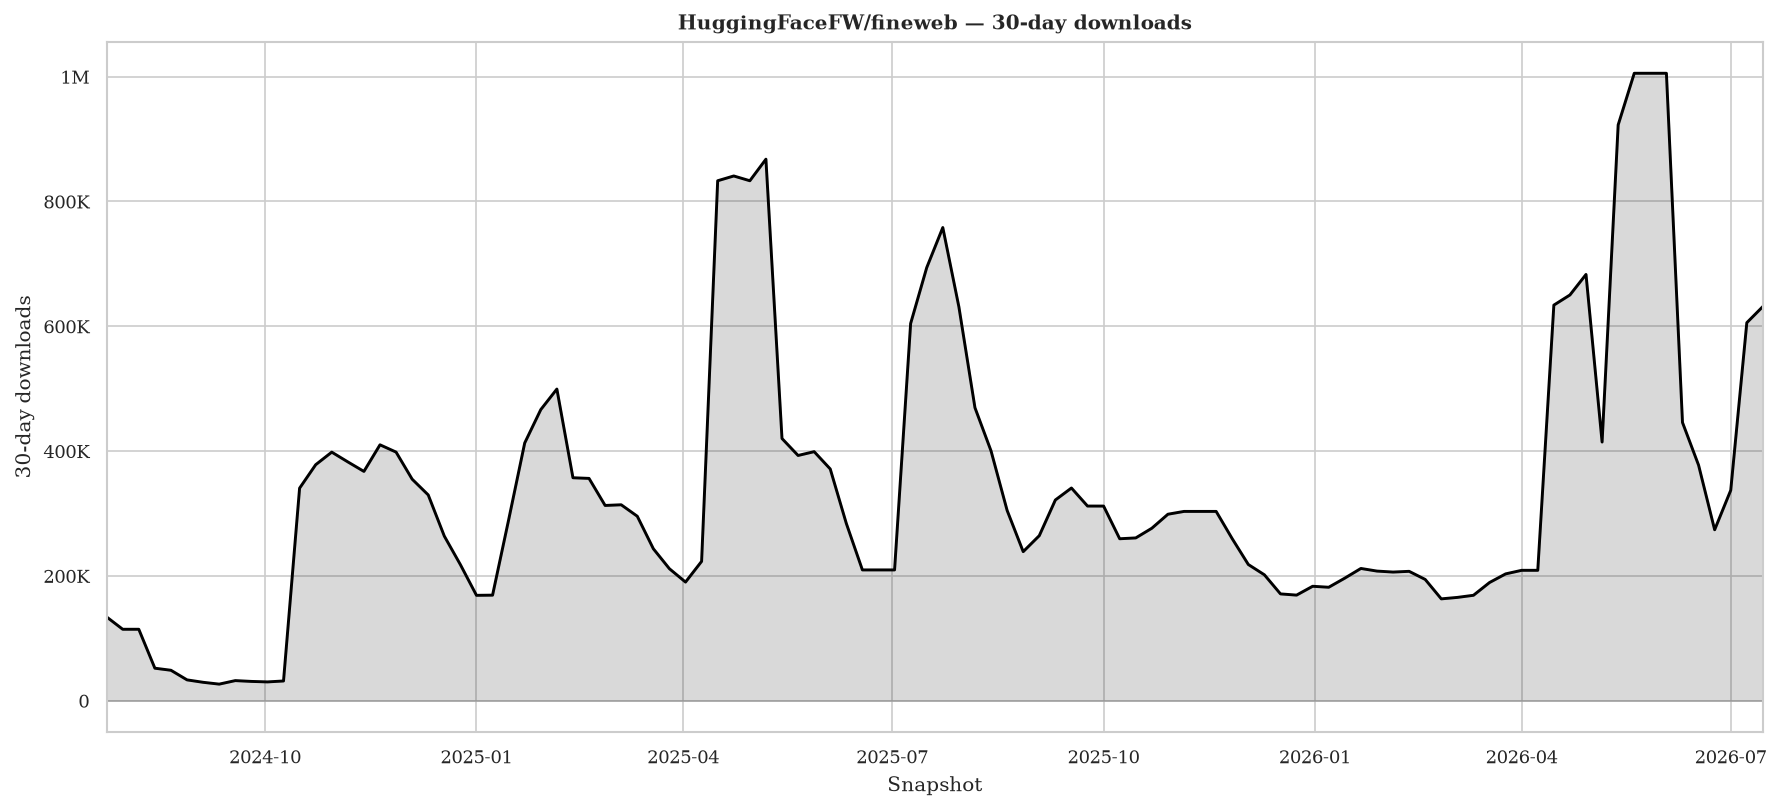

In [22]:
METRIC = "downloads"  # default = 30-day downloads. Try "downloadsAllTime" or "likes".

METRIC_LABELS = {
    "downloads": "30-day downloads",
    "downloadsAllTime": "Cumulative downloads",
    "likes": "Likes",
}
metric_label = METRIC_LABELS.get(METRIC, METRIC)

# downloadsAllTime is NULL before more_extensive_data_date — drop those rows for
# metrics that suffer from the early-era schema gap so the line doesn't plunge
# to zero on the left side of the chart.
series = ds_hist[METRIC]
if METRIC in {"downloadsAllTime"}:
    series = series.dropna()

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.plot(series.index, series.values, color="black", linewidth=1.4)
ax.fill_between(series.index, 0, series.values, color="black", alpha=0.15)
ax.set_xlabel("Snapshot")
ax.set_ylabel(metric_label)
ax.margins(x=0)
ax.yaxis.set_major_formatter(FuncFormatter(_fmt_big))
ax.set_title(f"{DATASET_ID} — {metric_label}")
fig.tight_layout()
plt.show()

# Licences over time

Licenses are not a separate column in the datasets min files — they live as
`license:<slug>` entries inside `tags`. Because tags exist since the very
first snapshot, these trends cover the FULL range (2024-07-24 →), unlike the
models version which only started at 2025-02-26.

In [23]:
# Active-population license trends from the weekly historic snapshots.
# At each snapshot we treat the on-Hub dataset set as the population, drop
# individuals, and split the rest into company vs. public organisations
# (every non-individual non-company org_type pooled). License strings are
# mapped to six buckets via the same LICENSE_TAXONOMY used in
# hf_main_licenses.ipynb -- redefined here so this file is self-contained.
#
# Caveat: org_type comes from a single 2026-04-30 org scrape applied to every
# snapshot. Company classification is stable, so the company-vs-other cut is
# the safest dimension to trend over time.

LICENSE_TAXONOMY = {
    # Permissive ----------------------------------------------------------
    "apache-2.0": ("Permissive", None), "mit": ("Permissive", None),
    "afl-3.0": ("Permissive", None), "artistic-2.0": ("Permissive", None),
    "bsl-1.0": ("Permissive", None), "bsd": ("Permissive", None),
    "bsd-2-clause": ("Permissive", None), "bsd-3-clause": ("Permissive", None),
    "bsd-3-clause-clear": ("Permissive", None), "ecl-2.0": ("Permissive", None),
    "isc": ("Permissive", None), "lppl-1.3c": ("Permissive", None),
    "ms-pl": ("Permissive", None), "mpl-2.0": ("Permissive", None),
    "ncsa": ("Permissive", None), "ofl-1.1": ("Permissive", None),
    "postgresql": ("Permissive", None), "unlicense": ("Permissive", None),
    "wtfpl": ("Permissive", None), "zlib": ("Permissive", None),
    "apple-ascl": ("Permissive", None), "openmdw-1.0": ("Permissive", None),
    "etalab-2.0": ("Permissive", None), "eupl-1.1": ("Permissive", None),
    "eupl-1.2": ("Permissive", None), "osl-3.0": ("Permissive", None),
    "agpl-3.0": ("Permissive", None), "gpl": ("Permissive", None),
    "gpl-2.0": ("Permissive", None), "gpl-3.0": ("Permissive", None),
    "lgpl": ("Permissive", None), "lgpl-2.1": ("Permissive", None),
    "lgpl-3.0": ("Permissive", None), "lgpl-lr": ("Permissive", None),
    "epl-1.0": ("Permissive", None), "epl-2.0": ("Permissive", None),
    "cc0-1.0": ("Permissive", None), "cc-by-2.0": ("Permissive", None),
    "cc-by-2.5": ("Permissive", None), "cc-by-3.0": ("Permissive", None),
    "cc-by-4.0": ("Permissive", None), "cc-by-sa-3.0": ("Permissive", None),
    "cc-by-sa-4.0": ("Permissive", None), "gfdl": ("Permissive", None),
    "pddl": ("Permissive", None), "odc-by": ("Permissive", None),
    "odbl": ("Permissive", None), "cdla-permissive-1.0": ("Permissive", None),
    "cdla-permissive-2.0": ("Permissive", None), "cdla-sharing-1.0": ("Permissive", None),
    "c-uda": ("Permissive", None),
    # AUP -- BigTech proprietary (Llama family, Gemma, Grok-2 community) ---
    "llama2": ("AUP", "BigTech"), "llama3": ("AUP", "BigTech"),
    "llama3.1": ("AUP", "BigTech"), "llama3.2": ("AUP", "BigTech"),
    "llama3.3": ("AUP", "BigTech"), "llama4": ("AUP", "BigTech"),
    "gemma": ("AUP", "BigTech"), "grok2-community": ("AUP", "BigTech"),
    # AUP -- Community / RAIL-Initiative ----------------------------------
    "openrail": ("AUP", "Community"), "openrail++": ("AUP", "Community"),
    "bigscience-openrail-m": ("AUP", "Community"),
    "creativeml-openrail-m": ("AUP", "Community"),
    "bigscience-bloom-rail-1.0": ("AUP", "Community"),
    "bigcode-openrail-m": ("AUP", "Community"),
    # Non-Commercial (CC-NC family + research-only ML licenses) -----------
    "cc-by-nc-2.0": ("Non-Commercial", None), "cc-by-nc-3.0": ("Non-Commercial", None),
    "cc-by-nc-4.0": ("Non-Commercial", None),
    "cc-by-nc-sa-2.0": ("Non-Commercial", None),
    "cc-by-nc-sa-3.0": ("Non-Commercial", None),
    "cc-by-nc-sa-4.0": ("Non-Commercial", None),
    "cc-by-nc-nd-3.0": ("Non-Commercial", None),
    "cc-by-nc-nd-4.0": ("Non-Commercial", None),
    "cc-by-nd-4.0": ("Non-Commercial", None),
    "apple-amlr": ("Non-Commercial", None),
    "deepfloyd-if-license": ("Non-Commercial", None),
    "fair-noncommercial-research-license": ("Non-Commercial", None),
    "h-research": ("Non-Commercial", None),
    "intel-research": ("Non-Commercial", None),
    # Other -- intentionally uninformative declared licenses --------------
    "cc": ("Other", None), "other": ("Other", None), "unknown": ("Other", None),
}

LICENSE_GROUPS_ORDERED = [
    "Permissive", "AUP (Community)", "AUP (BigTech)",
    "Non-Commercial", "Other", "unspecified",
]
LICENSE_GROUP_COLORS = {
    "Permissive":      (0.00784313725490196, 0.6196078431372549, 0.45098039215686275),
    "AUP (Community)": (0.8705882352941177, 0.5607843137254902, 0.0196078431372549),
    "AUP (BigTech)":   (0.8352941176470589, 0.3686274509803922, 0.0),
    "Non-Commercial":  (0.8, 0.47058823529411764, 0.7372549019607844),
    "Other":           (0.6, 0.6, 0.6),
    "unspecified":     (0.75, 0.75, 0.75),
}


def license_from_tags(tags) -> str | None:
    """First `license:<slug>` tag, stripped of the prefix.

    A handful of datasets declare several license tags; those map to "Other" in
    the taxonomy anyway, so we just take the first to keep one value per row.
    """
    if tags is None or len(tags) == 0:
        return None
    for t in tags:
        if t.startswith("license:"):
            return t[len("license:"):]
    return None


def _license_group(lic):
    if lic is None or pd.isna(lic):
        return "unspecified"
    cat, sub = LICENSE_TAXONOMY.get(lic, ("Other", None))
    if cat == "AUP":
        return f"AUP ({sub})"
    return cat


def license_org_shares_over_time(
    start_date: str = first_date,
    hist_dir: str = HIST_DATA_DIR,
) -> pd.DataFrame:
    """For each weekly snapshot >= start_date, aggregate dataset counts and
    30-day download sums per (org_group, license_group).

    Returns tidy long-form: snapshot | org_group | license_group | n | downloads.
    org_group = 'company' if org_type == 'company' else 'public organisations';
    rows with org_type == 'individual' (or NaN) are dropped first.
    """
    out = []
    for d, p in _snapshot_files(hist_dir, start_date):
        df = pd.read_parquet(p, columns=["tags", "org_type", "downloads"])
        df["org_type"] = df["org_type"].fillna("individual")
        df = df[df["org_type"] != "individual"]
        df = df.assign(
            org_group=np.where(df["org_type"] == "company", "company", "public organisations"),
            license_group=df["tags"].map(license_from_tags).map(_license_group),
        )
        agg = (
            df.groupby(["org_group", "license_group"])
              .agg(n=("license_group", "size"), downloads=("downloads", "sum"))
              .reset_index()
              .assign(snapshot=d)
        )
        out.append(agg)
    return pd.concat(out, ignore_index=True)


lic_hist = license_org_shares_over_time()
print(f"{lic_hist['snapshot'].nunique()} snapshots, "
      f"{lic_hist['snapshot'].min():%Y-%m-%d} -> {lic_hist['snapshot'].max():%Y-%m-%d}")
lic_hist.head()

104 snapshots, 2024-07-24 -> 2026-07-15


,org_group,license_group,n,downloads,snapshot
0,company,AUP (BigTech),7,898,2024-07-24
1,company,AUP (Community),44,2049,2024-07-24
2,company,Non-Commercial,194,82205,2024-07-24
3,company,Other,316,56300,2024-07-24
4,company,Permissive,1649,1513051,2024-07-24


Share of datasets per license group, by weekly snapshot (2024-07-24 -> 2026-07-15). Population at each snapshot: org_type != 'individual', split into company vs. public organisations. Each panel = one license group; solid = company, dashed = other. License derived from `license:` tags. Caveat: org_type is from a 2026-04-30 scrape applied to every snapshot.


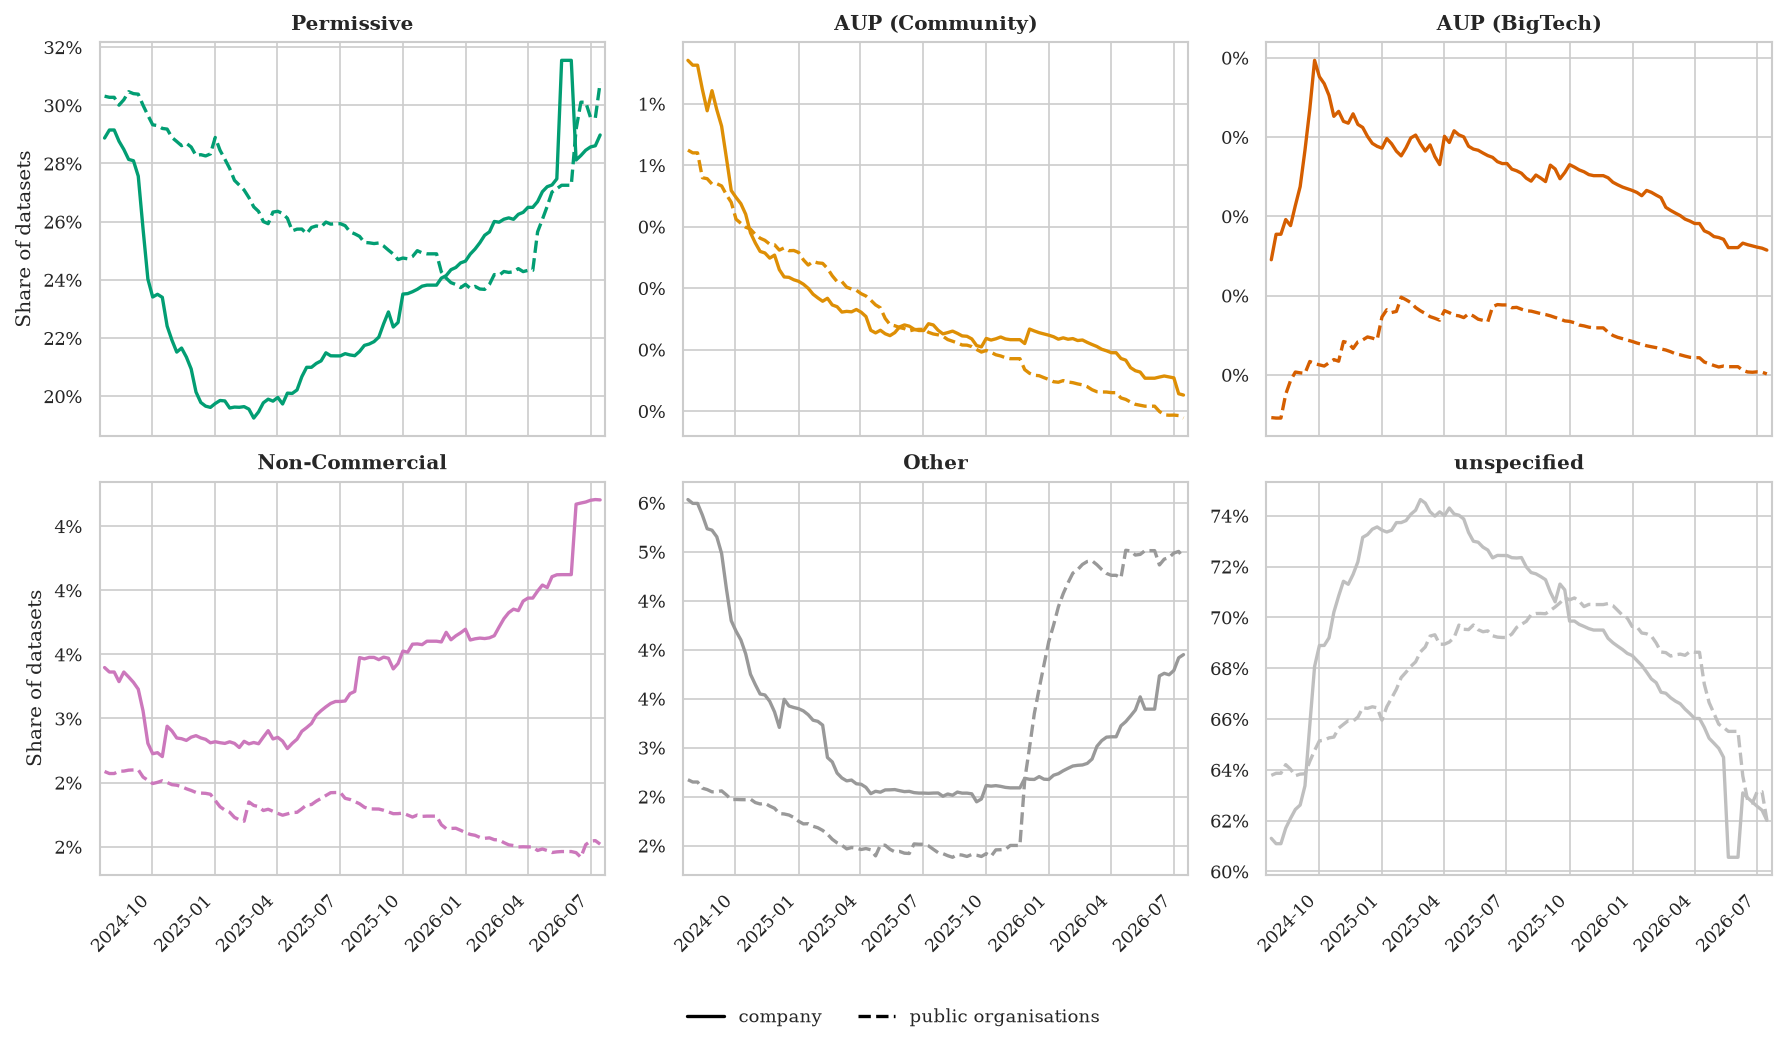

In [24]:
# Active-population view #1 -- share of DATASETS per license group, per snapshot,
# split by org_group (6 panels, company solid / public organisations dashed).
ORG_GROUPS = ["company", "public organisations"]
ORG_LINESTYLE = {"company": "-", "public organisations": "--"}

wide_n = (
    lic_hist.pivot_table(index="snapshot", columns=["org_group", "license_group"],
                         values="n", fill_value=0)
            .reindex(columns=pd.MultiIndex.from_product([ORG_GROUPS, LICENSE_GROUPS_ORDERED]),
                     fill_value=0)
            .sort_index()
)
# Per-snapshot total datasets per org_group (denominator for the within-group share).
totals_n = wide_n.T.groupby(level=0).sum().T
shares_n = wide_n.div(totals_n, level=0, axis=1).fillna(0)

fig, axes = plt.subplots(2, 3, figsize=(12, 7), sharex=True, sharey=False)
for ax, lg in zip(axes.flat, LICENSE_GROUPS_ORDERED):
    colour = LICENSE_GROUP_COLORS[lg]
    for og in ORG_GROUPS:
        ax.plot(shares_n.index, shares_n[(og, lg)].values,
                color=colour, linestyle=ORG_LINESTYLE[og], linewidth=1.6)
    ax.set_title(lg)
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
    ax.margins(x=0.01)

for ax in axes[:, 0]:
    ax.set_ylabel("Share of datasets")
for ax in axes[-1, :]:
    for lbl in ax.get_xticklabels():
        lbl.set_rotation(45)
        lbl.set_ha("right")

legend_handles = [
    Line2D([0], [0], color="black", linestyle=ORG_LINESTYLE[og], linewidth=1.6, label=og)
    for og in ORG_GROUPS
]
fig.legend(handles=legend_handles, loc="lower center",
           ncol=len(ORG_GROUPS), bbox_to_anchor=(0.5, 0), frameon=False)

fig.tight_layout()
fig.subplots_adjust(bottom=0.16)

print(
    "Share of datasets per license group, by weekly snapshot "
    f"({shares_n.index.min():%Y-%m-%d} -> {shares_n.index.max():%Y-%m-%d}). "
    "Population at each snapshot: org_type != 'individual', split into company vs. "
    "public organisations. Each panel = one license group; solid = company, dashed = other. "
    "License derived from `license:` tags. Caveat: org_type is from a 2026-04-30 scrape "
    "applied to every snapshot."
)
plt.show()

Absolute number of datasets per license group, by weekly snapshot (2024-07-24 -> 2026-07-15). Same population split as the share chart; y-axis starts at 0 in every panel; panels have independent y-ranges.


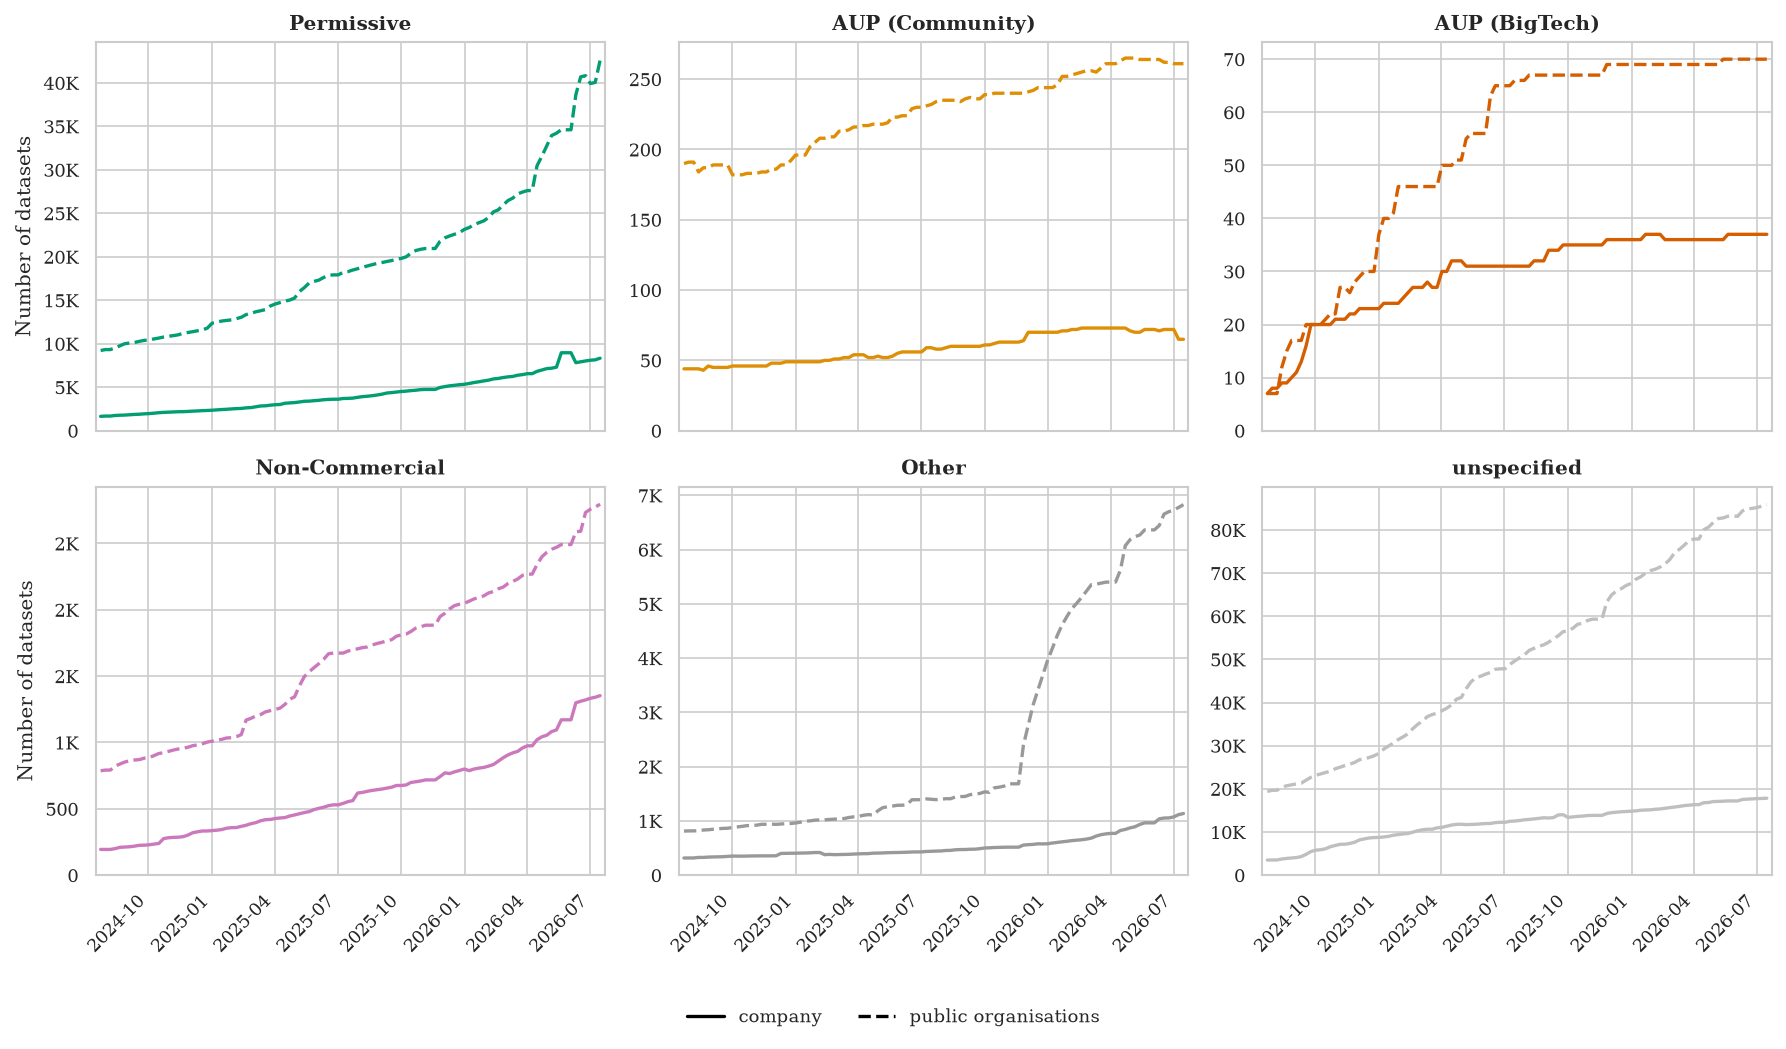

In [25]:
# Same structure, but ABSOLUTE dataset counts instead of within-org-group share.
counts_n = wide_n.copy()

fig, axes = plt.subplots(2, 3, figsize=(12, 7), sharex=True, sharey=False)
for ax, lg in zip(axes.flat, LICENSE_GROUPS_ORDERED):
    colour = LICENSE_GROUP_COLORS[lg]
    for og in ORG_GROUPS:
        ax.plot(counts_n.index, counts_n[(og, lg)].values,
                color=colour, linestyle=ORG_LINESTYLE[og], linewidth=1.6)
    ax.set_title(lg)
    ax.yaxis.set_major_formatter(FuncFormatter(_fmt_big))
    ax.margins(x=0.01)
    ax.set_ylim(bottom=0)

for ax in axes[:, 0]:
    ax.set_ylabel("Number of datasets")
for ax in axes[-1, :]:
    for lbl in ax.get_xticklabels():
        lbl.set_rotation(45)
        lbl.set_ha("right")

legend_handles = [
    Line2D([0], [0], color="black", linestyle=ORG_LINESTYLE[og], linewidth=1.6, label=og)
    for og in ORG_GROUPS
]
fig.legend(handles=legend_handles, loc="lower center",
           ncol=len(ORG_GROUPS), bbox_to_anchor=(0.5, 0), frameon=False)

fig.tight_layout()
fig.subplots_adjust(bottom=0.16)

print(
    "Absolute number of datasets per license group, by weekly snapshot "
    f"({counts_n.index.min():%Y-%m-%d} -> {counts_n.index.max():%Y-%m-%d}). "
    "Same population split as the share chart; y-axis starts at 0 in every panel; "
    "panels have independent y-ranges."
)
plt.show()

Share of 30-day downloads per license group, by weekly snapshot (2024-07-24 -> 2026-07-15). Same population split as the count chart (individuals excluded). Note: a few viral datasets can dominate within-org download share, so single-dataset weeks may move lines more than the underlying license mix.


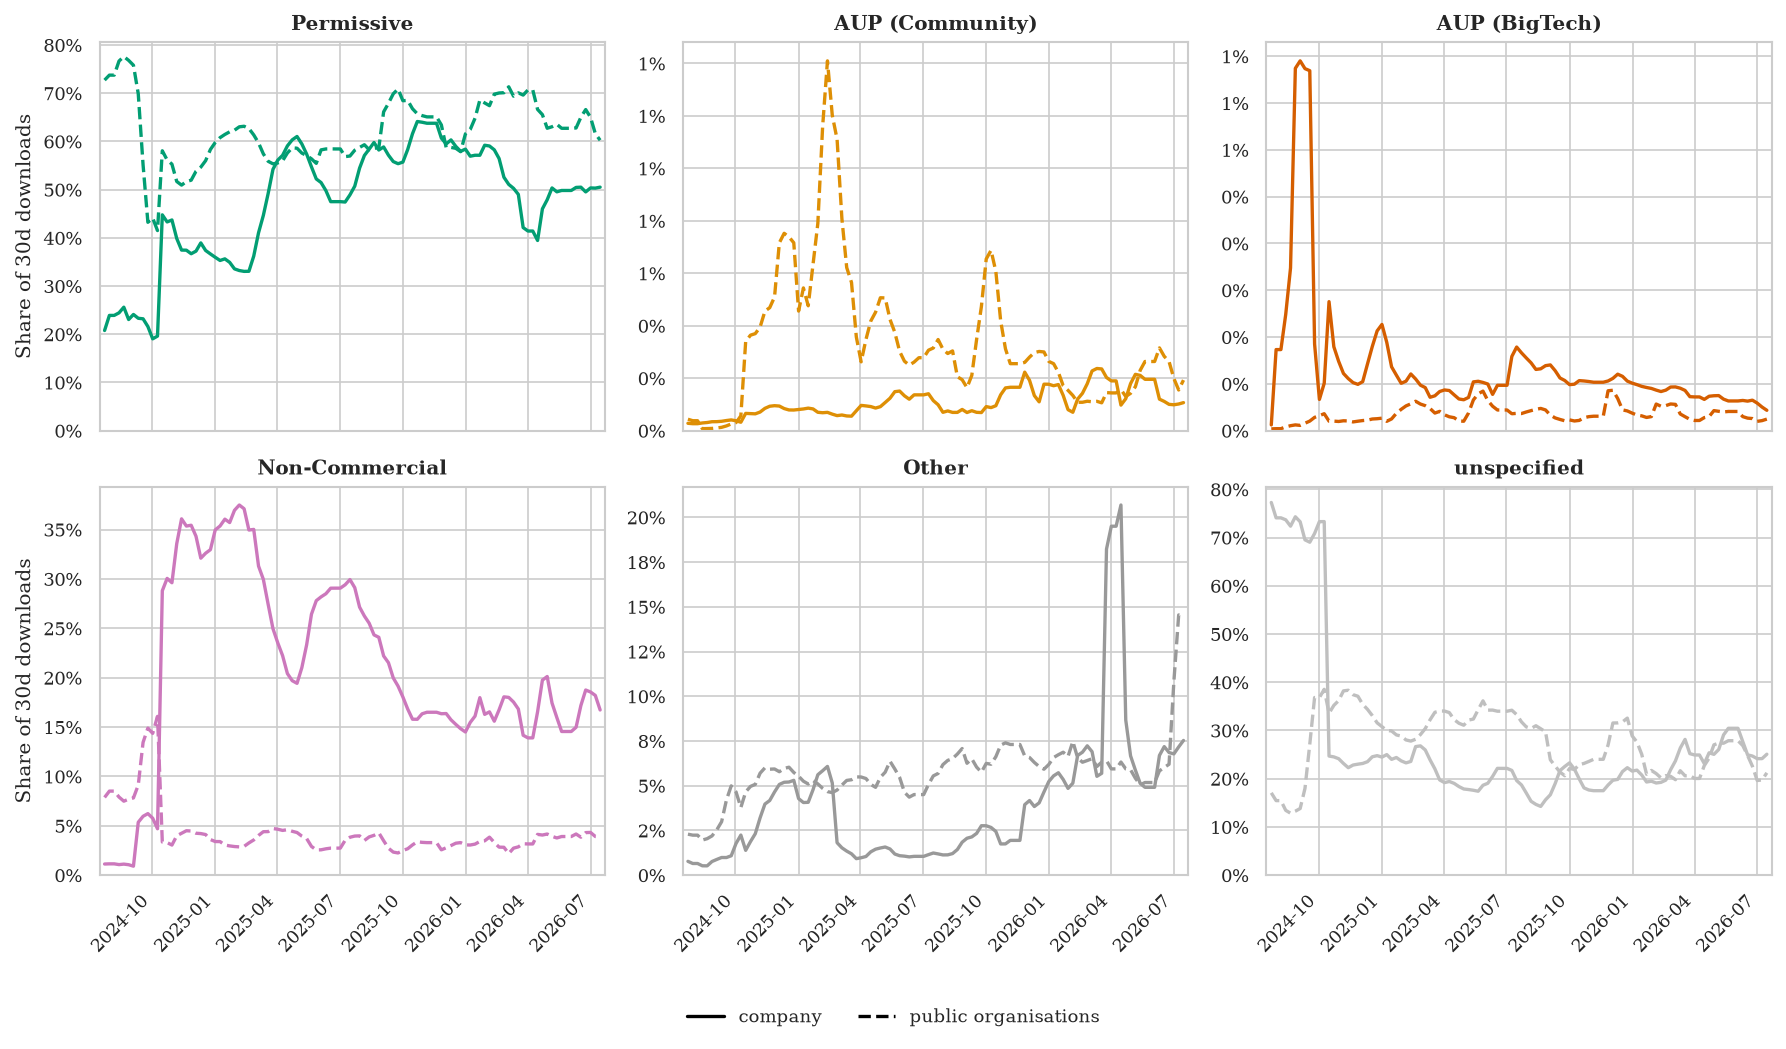

In [26]:
# Active-population view #2 -- same structure, weighted by 30-day download sums.
wide_dl = (
    lic_hist.pivot_table(index="snapshot", columns=["org_group", "license_group"],
                         values="downloads", fill_value=0)
            .reindex(columns=pd.MultiIndex.from_product([ORG_GROUPS, LICENSE_GROUPS_ORDERED]),
                     fill_value=0)
            .sort_index()
)
totals_dl = wide_dl.T.groupby(level=0).sum().T
shares_dl = wide_dl.div(totals_dl, level=0, axis=1).fillna(0)

fig, axes = plt.subplots(2, 3, figsize=(12, 7), sharex=True, sharey=False)
for ax, lg in zip(axes.flat, LICENSE_GROUPS_ORDERED):
    colour = LICENSE_GROUP_COLORS[lg]
    for og in ORG_GROUPS:
        ax.plot(shares_dl.index, shares_dl[(og, lg)].values,
                color=colour, linestyle=ORG_LINESTYLE[og], linewidth=1.6)
    ax.set_title(lg)
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
    ax.margins(x=0.01)
    ax.set_ylim(bottom=0)

for ax in axes[:, 0]:
    ax.set_ylabel("Share of 30d downloads")
for ax in axes[-1, :]:
    for lbl in ax.get_xticklabels():
        lbl.set_rotation(45)
        lbl.set_ha("right")

legend_handles = [
    Line2D([0], [0], color="black", linestyle=ORG_LINESTYLE[og], linewidth=1.6, label=og)
    for og in ORG_GROUPS
]
fig.legend(handles=legend_handles, loc="lower center",
           ncol=len(ORG_GROUPS), bbox_to_anchor=(0.5, 0), frameon=False)

fig.tight_layout()
fig.subplots_adjust(bottom=0.16)

print(
    "Share of 30-day downloads per license group, by weekly snapshot "
    f"({shares_dl.index.min():%Y-%m-%d} -> {shares_dl.index.max():%Y-%m-%d}). "
    "Same population split as the count chart (individuals excluded). "
    "Note: a few viral datasets can dominate within-org download share, so "
    "single-dataset weeks may move lines more than the underlying license mix."
)
plt.show()